In [1]:
%pip install numpy
%pip install scipy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import numpy.linalg as linalg
from scipy.integrate import ode
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle
import ipywidgets as widgets
from IPython.display import display

In [14]:
def get_basis_1(t: float, get_surface_angles) -> np.ndarray:
    alpha = get_surface_angles(t)[0]
    return np.array([np.cos(alpha), 0,  np.sin(alpha)])


def get_basis_2(t: float, get_surface_angles) -> np.ndarray:
    beta = get_surface_angles(t)[1]
    return np.array([0, np.cos(beta), np.sin(beta)])
    

def get_surface_normal(t: float, get_surface_angles) -> np.ndarray:
    cross_product = np.cross(get_basis_1(t, get_surface_angles), get_basis_2(t, get_surface_angles))
    return cross_product / linalg.norm(cross_product)

In [31]:
g = 9.8
EPSILON = 1e-3


def solve_rolling(r: float, m: float, I: float, friction_coefficient: float, get_surface_angles,
                  v0: np.ndarray, w0: np.ndarray, max_t: float, dt: float = 0.01
                  ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    def compute_gravity_proj(t: float) -> np.ndarray:
        basis_change_matrix = np.array([get_basis_1(t, get_surface_angles), 
                                        get_basis_2(t, get_surface_angles), 
                                        get_surface_normal(t, get_surface_angles)]).T 

        full_gravity = np.array([0, 0, -m * g])
        projected_gravity = (linalg.inv(basis_change_matrix) @ full_gravity)
        return projected_gravity[:2]


    def compute_friction(t: float, v: np.ndarray, w: np.ndarray, gravity: np.ndarray) -> np.ndarray:
        v_contact = v - np.array([w[1], -w[0]]) * r

        max_friction = -np.dot(friction_coefficient * np.array([0, 0, -m * g]), 
                               get_surface_normal(t, get_surface_angles))

        stable_friction = gravity * (1 - 1 / (I / m / r ** 2 + 1))
        if linalg.norm(stable_friction) > max_friction:
            stable_friction = gravity / linalg.norm(gravity)

        if linalg.norm(v_contact) > EPSILON:
            return max_friction * v_contact / linalg.norm(v_contact)
        else:
            return stable_friction


    def derivatives(t: float, state: np.ndarray) -> np.ndarray:
        v = state[2:4]
        w = state[4:]

        gravity = compute_gravity_proj(t)
        friction = compute_friction(t, v, w, gravity)

        derivatives = np.array([
            *v,
            *(gravity - friction),
            -friction[1] * r / I,
            friction[0] * r / I,
        ])
        return derivatives

    integrator = ode(derivatives)
    integrator.set_initial_value(np.array([0, 0, *v0, *w0]), 0)
    integrator.set_integrator('dopri5', rtol=1e-6)

    t_values = []
    path_values = []
    v_values = []
    w_values = []

    while integrator.successful() and integrator.t < max_t:
        x, y, v_x, v_y, w_x, w_y = integrator.integrate(integrator.t + dt)
        t_values.append(integrator.t)
        path_values.append((x, y))
        v_values.append((v_x, v_y))
        w_values.append((w_x, w_y))

    return (np.array(t_values), np.array(path_values), np.array(v_values), np.array(w_values))

In [149]:
from typing import Optional

def show_analysis(r: float, m: float, I: float, friction_coefficient: float, get_surface_angles,
                  v0: np.ndarray, w0: np.ndarray, show_t: float, max_t: Optional[float] = None, shown_area_size: float = 1, dt: float = 0.01) -> None:
    if max_t is None:
        max_t = show_t

    t, path, v, w = solve_rolling(r, m, I, friction_coefficient, get_surface_angles, v0, w0, max_t, dt)

    plt.figure(figsize=(12, 12))

    plt.plot(path[:, 0], path[:, 1])

    plt.title('Траектория')
    plt.xlabel('x')
    plt.ylabel('y')
    
    plt.xlim(-shown_area_size, shown_area_size)
    plt.ylim(-shown_area_size, shown_area_size)

    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 8))

    last_shown = t.searchsorted(show_t)
    plt.plot(t[:last_shown], linalg.norm(v[:last_shown], axis=1), label='Скорость центра масс')
    plt.plot(t[:last_shown], linalg.norm(w[:last_shown] * r, axis=1), label='Скорость вращения поверхности')

    plt.title('Скорости')
    plt.xlabel('Время, с')
    plt.ylabel('Скорость, м/с')
    plt.legend()
    plt.grid(True)
    plt.show()

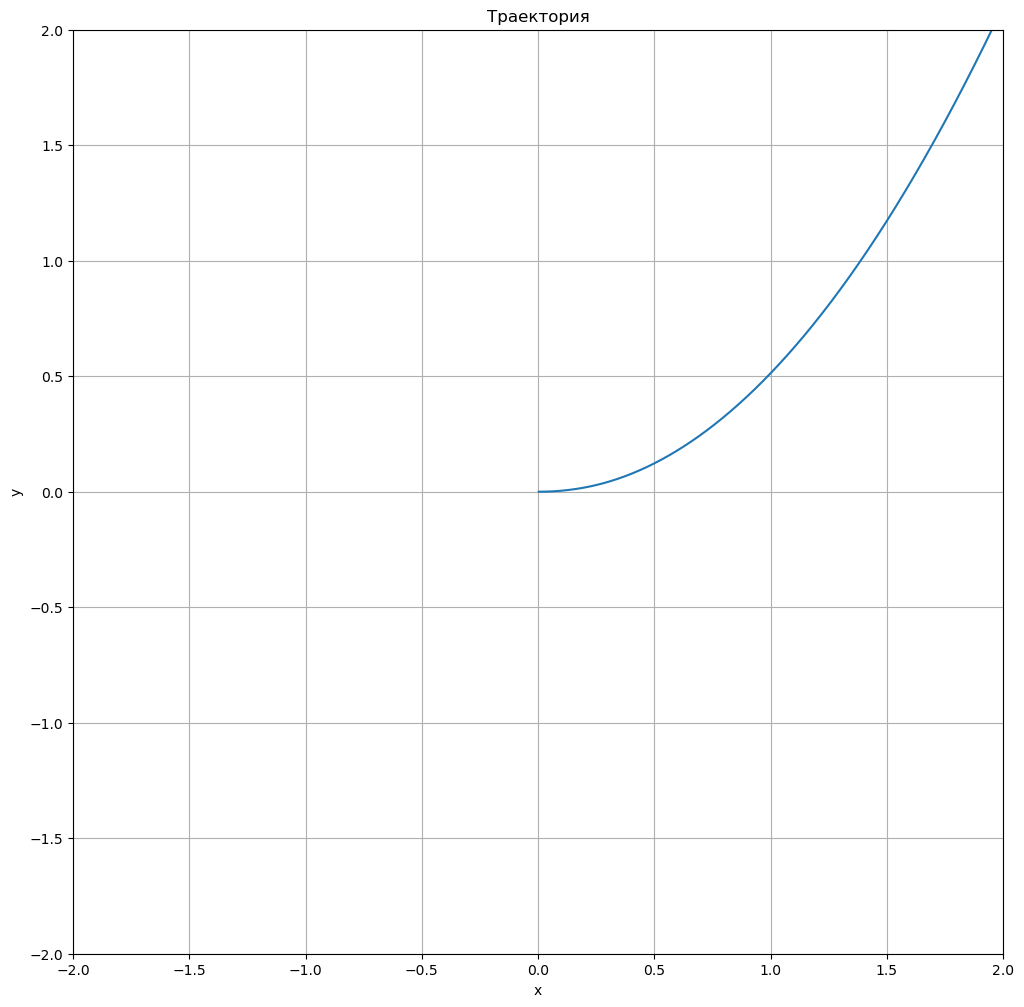

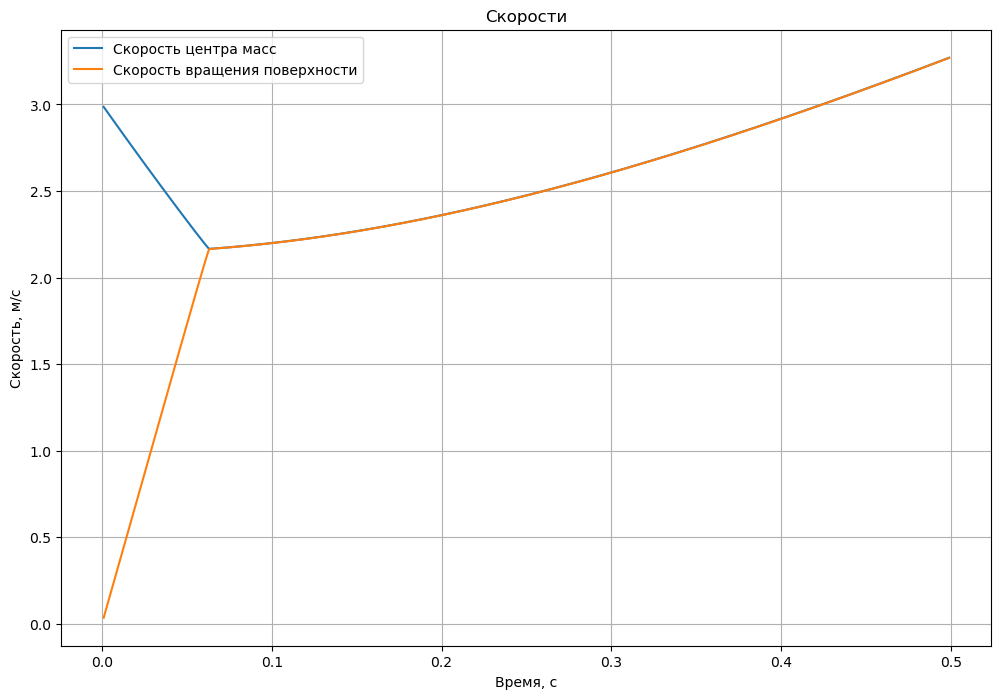

In [150]:
show_analysis(1, 1, 2 / 5, 2, (lambda _: np.array([0.0, -np.pi / 4])), np.array([3, 0]), np.array([0, 0]), 
              show_t=0.5, max_t=1, shown_area_size=2, dt=0.001)

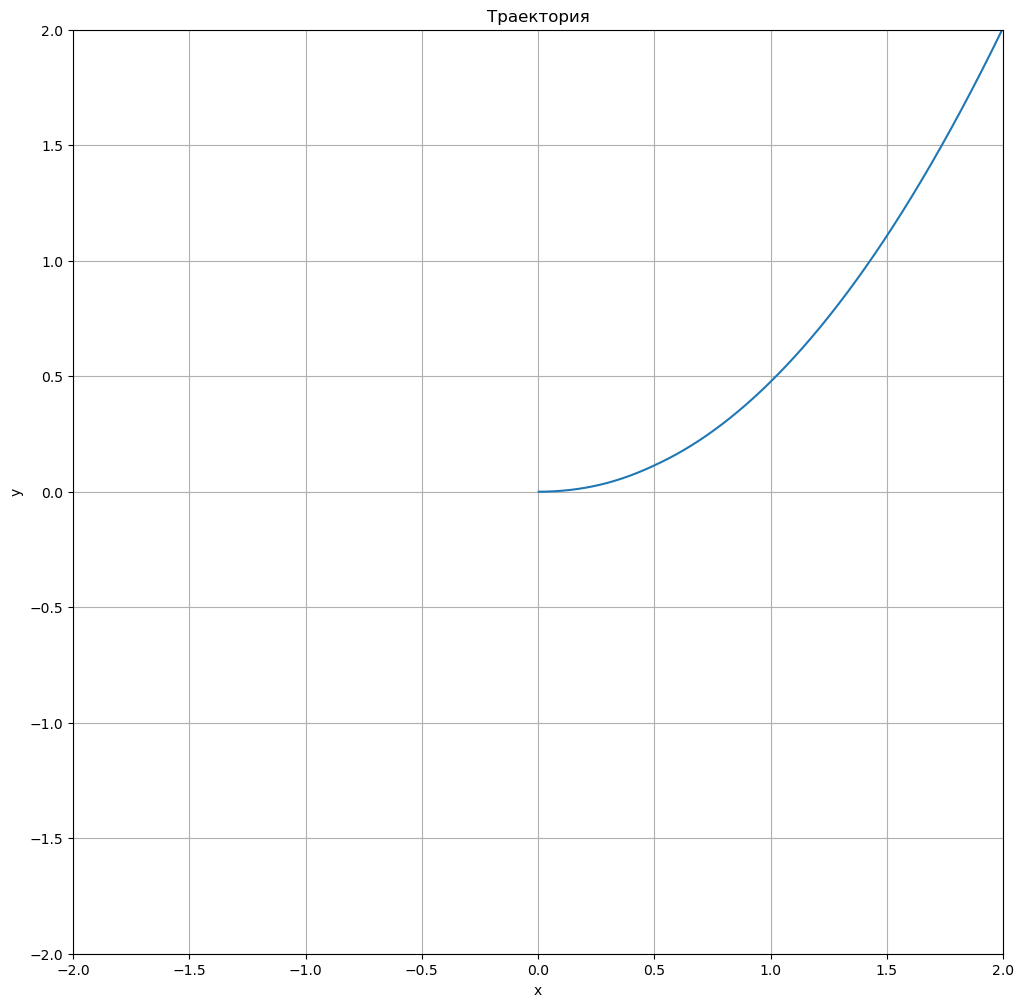

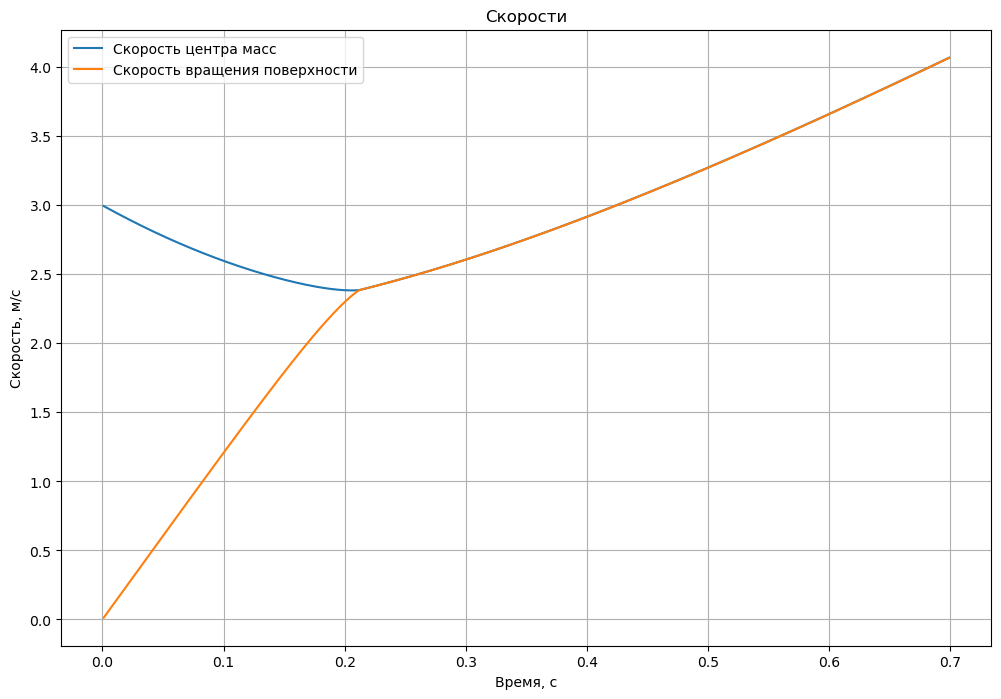

In [160]:
show_analysis(1, 1, 2 / 5, 0.7, (lambda _: np.array([0.0, -np.pi / 4])), np.array([3, 0]), np.array([0, 0]), 
              show_t=0.7, max_t=1, shown_area_size=2, dt=0.001)

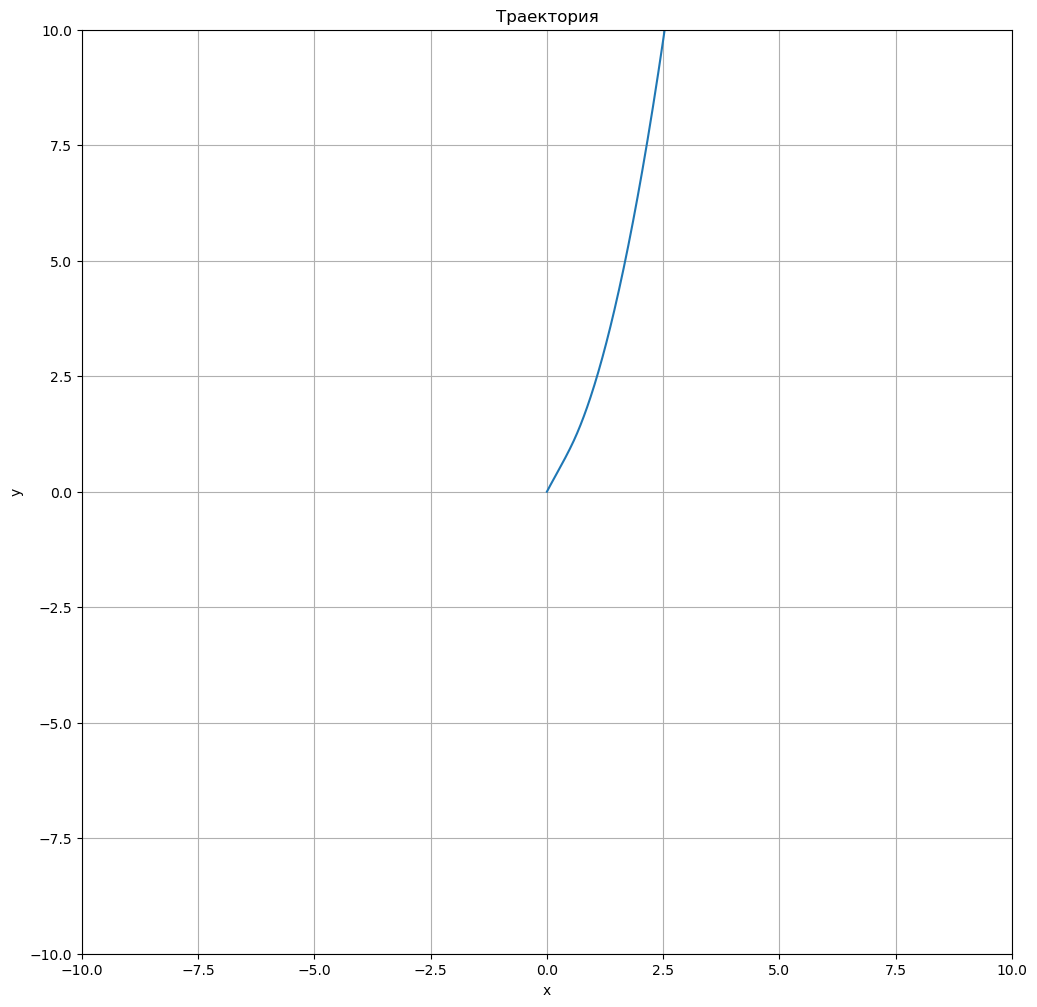

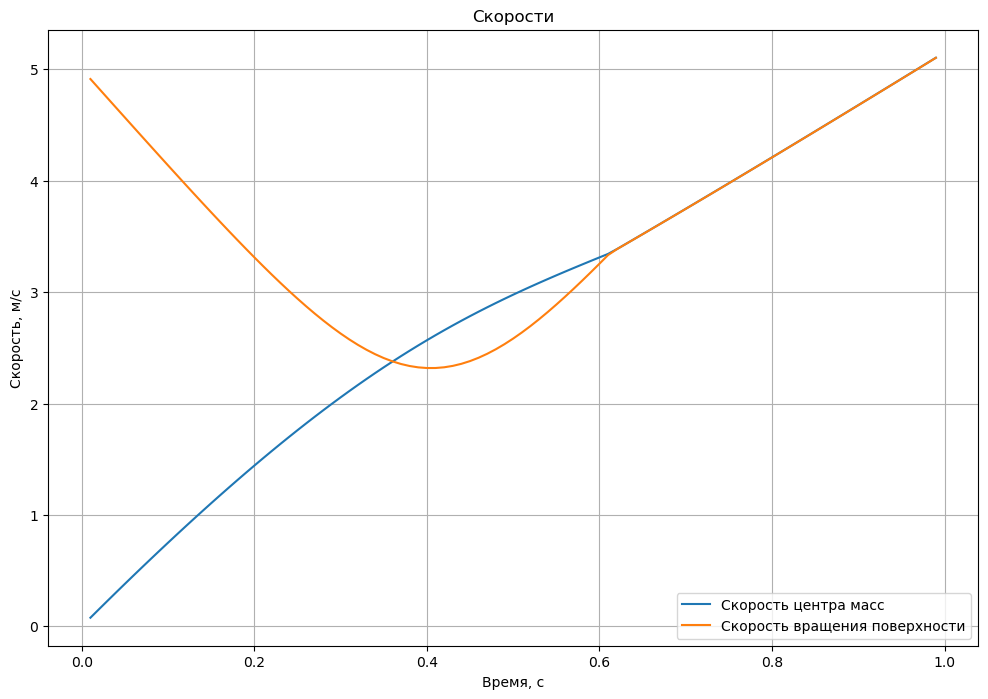

In [190]:
show_analysis(1, 1, 2 / 5, 0.5, (lambda _: np.array([0.0, -np.pi / 4])), np.array([0, 0]), np.array([0, 5]), 1, shown_area_size=10, max_t=5)

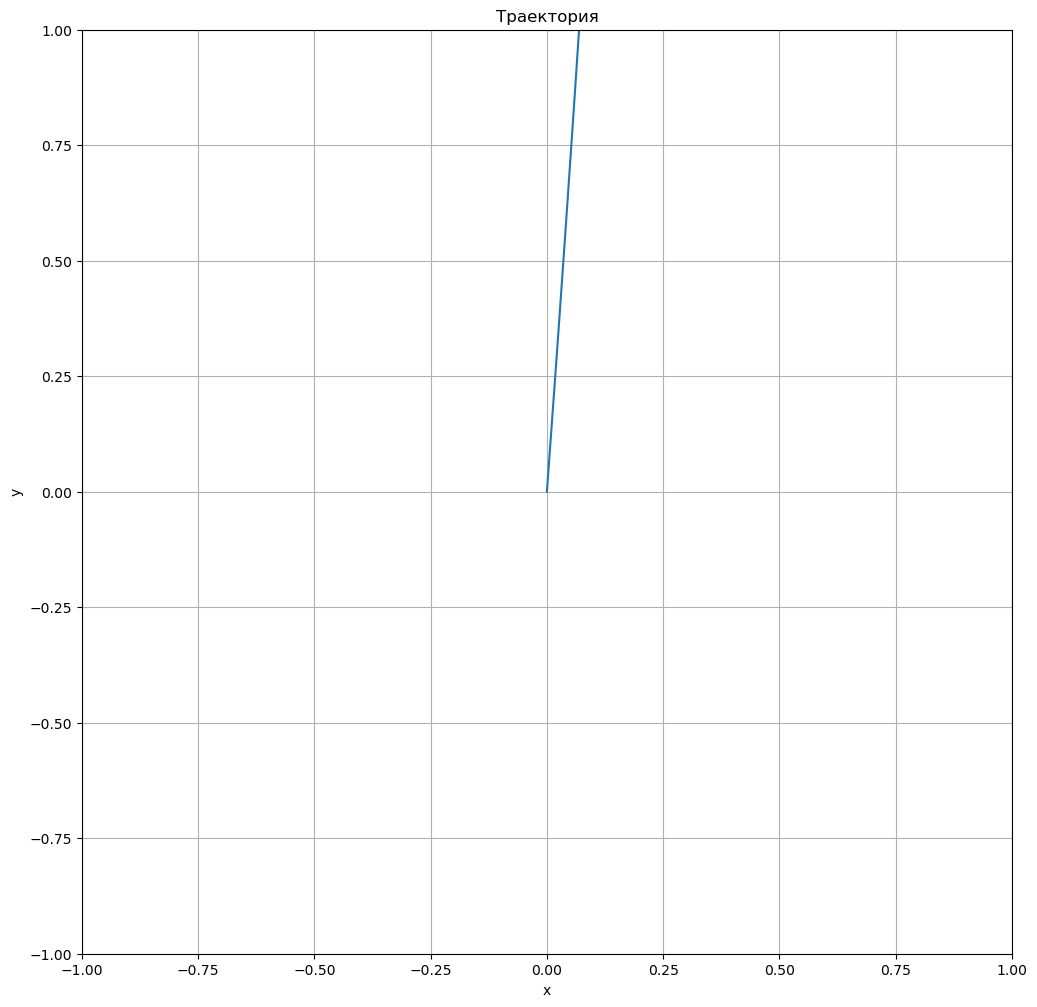

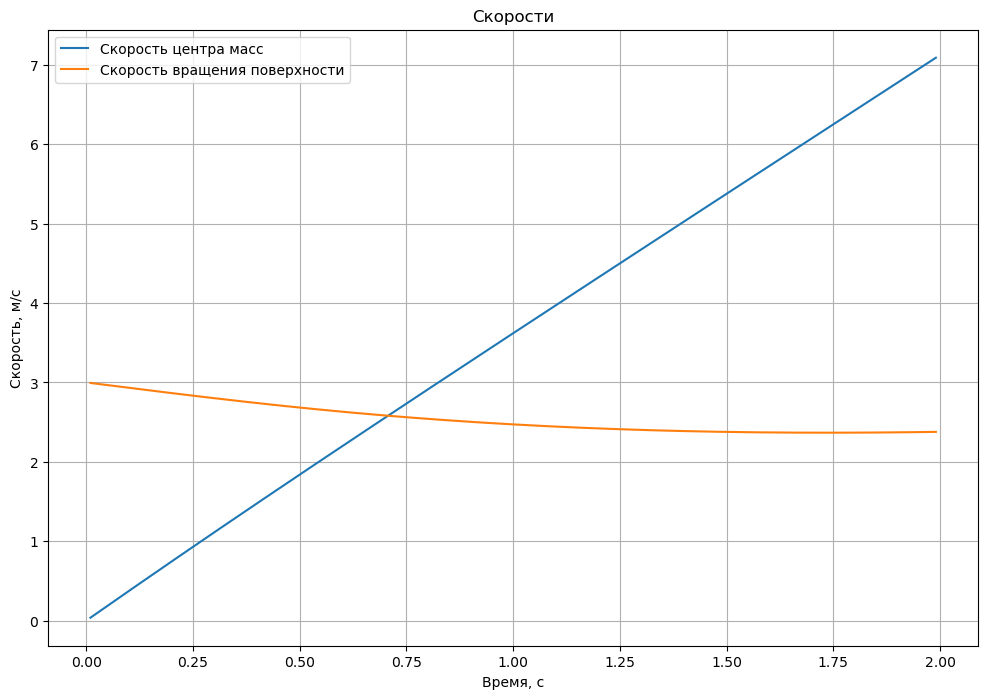

In [227]:
show_analysis(1, 1, 2 / 5, 0.03, (lambda _: np.array([0.0, -np.pi / 8])), np.array([0, 0]), np.array([0, 3]), 2, shown_area_size=1)